### Business Problem

The market research team at AeroFit wants to identify the characteristics of the target audience for each type of treadmill offered by the company, to provide a better recommendation of the treadmills to the new customers. The team decides to investigate whether there are differences across the product with respect to customer characteristics.  

### Business Objectives

1. Create a customer profile for each Aerofit traedmill product.
2. Derive insights and business impacts for each Aerofit treadmill product to recommend right product for a customer profile.

### Data Understanding

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("aerofit_treadmill.txt")

In [3]:
# displaying 1st five rows
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [4]:
# checking rows and columns
df.shape

(180, 9)

In [5]:
# Checking data types of each columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Product        180 non-null    str  
 1   Age            180 non-null    int64
 2   Gender         180 non-null    str  
 3   Education      180 non-null    int64
 4   MaritalStatus  180 non-null    str  
 5   Usage          180 non-null    int64
 6   Fitness        180 non-null    int64
 7   Income         180 non-null    int64
 8   Miles          180 non-null    int64
dtypes: int64(6), str(3)
memory usage: 12.8 KB


In [6]:
df["Education"].unique()

array([14, 15, 12, 13, 16, 18, 20, 21])

In [7]:
df["Usage"].unique()

array([3, 2, 4, 5, 6, 7])

In [8]:
df["Fitness"].unique()

array([4, 3, 2, 1, 5])

In [9]:
df["Income"].unique()

array([ 29562,  31836,  30699,  32973,  35247,  37521,  36384,  38658,
        40932,  34110,  39795,  42069,  44343,  45480,  46617,  48891,
        53439,  43206,  52302,  51165,  50028,  54576,  68220,  55713,
        60261,  67083,  56850,  59124,  61398,  57987,  64809,  47754,
        65220,  62535,  48658,  54781,  48556,  58516,  53536,  61006,
        57271,  52291,  49801,  62251,  64741,  70966,  75946,  74701,
        69721,  83416,  88396,  90886,  92131,  77191,  52290,  85906,
       103336,  99601,  89641,  95866, 104581,  95508])

In [10]:
df["Income"].duplicated().sum()

np.int64(118)

In [11]:
df["Miles"].unique(), df["Miles"].duplicated().sum()

(array([112,  75,  66,  85,  47, 141, 103,  94, 113,  38, 188,  56, 132,
        169,  64,  53, 106,  95, 212,  42, 127,  74, 170,  21, 120, 200,
        140, 100,  80, 160, 180, 240, 150, 300, 280, 260, 360]),
 np.int64(143))

**Data types of all the attributes**  
1. Product - Categorical (nominal)
2. Age - Numerical (discrete)
3. Gender - Categorical (nominal)
4. Education - Numerical (discrete)
5. MaritalStatus - Categorical (nominal)
6. Usage - Numerical (discrete)
7. Fitness - Numerical (discrete)
8. Income - Numerical (continuous)
9. Miles - Numerical (continuous)

In [12]:
# Statistical summary
df.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


In [13]:
# Checking for null values
df.isna().sum()

Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64

In [14]:
df.nunique()

Product           3
Age              32
Gender            2
Education         8
MaritalStatus     2
Usage             6
Fitness           5
Income           62
Miles            37
dtype: int64

1. There are total 180 records and 9 features with no null or missing values for any column, so data is ready for analysis.
2. Fitness column needs to be changed to "Categorical (ordinal)" because it has a level of comparison, example, person with fitness level 1 is less fit than person with fitness level 3.
3. Standard deviation for income is high which means customers from diverse income range are buying products.
4. Customers are between 18 to 50 years old with mean 28 which means majority of customers are young adults.

### Data Analysis

In [15]:
# which products are offered and what is there distribution
df["Product"].unique()

<StringArray>
['KP281', 'KP481', 'KP781']
Length: 3, dtype: str

In [16]:
# Percentage distribution of product category purchase
np.round(df["Product"].value_counts(normalize=True) * 100, 2)

Product
KP281    44.44
KP481    33.33
KP781    22.22
Name: proportion, dtype: float64

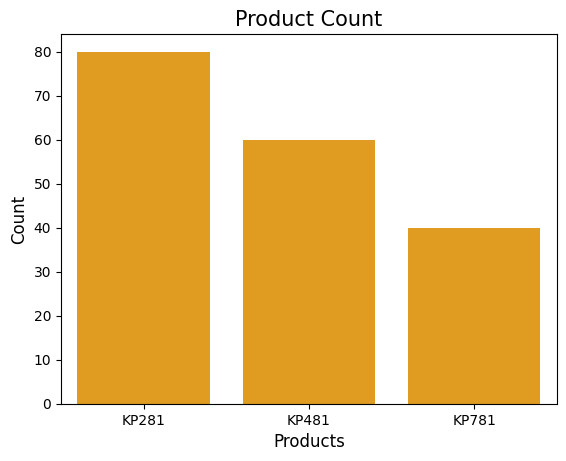

In [17]:
# creating visualization for product purchases
sns.countplot(df, x="Product", color="orange")
plt.xlabel("Products", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Product Count", fontsize=15)

plt.show()

1. KP281, an entry-level product is most purchased product (around 45%) and KP781, product with advanced features is the least purchased (around 22%) and KP481 contributes to 33% purchase.
2. The highest sale of KP281 may suggest that most of the customer prefer affordable or beginner-level product.

In [18]:
# How is the gender distribution among the customers
np.round(df["Gender"].value_counts(normalize=True) * 100, 2)

Gender
Male      57.78
Female    42.22
Name: proportion, dtype: float64

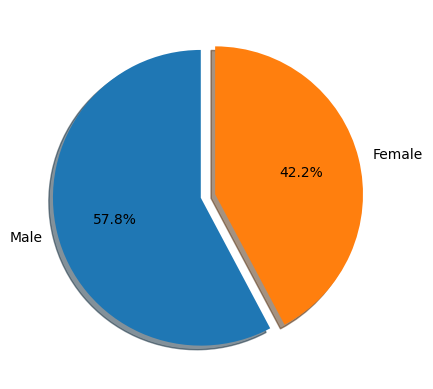

In [19]:
# Gender distribution pie chart
plt.pie(x=df["Gender"].value_counts(), labels=df["Gender"].value_counts().index, autopct='%1.1f%%', explode=(0.1,0), shadow=True, startangle=90)

plt.show()

1. Male customer dominate the product purchases with around 58% while female also contribute to the purchase with 42% showing both genders contribute almost equally.

In [20]:
# How is the fitness level distribution among customers
np.round(df["Fitness"].value_counts(normalize=True) * 100, 2)

Fitness
3    53.89
5    17.22
2    14.44
4    13.33
1     1.11
Name: proportion, dtype: float64

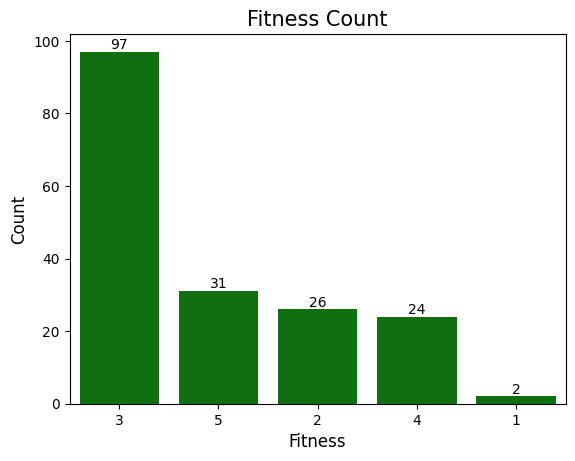

In [21]:
# visualization for Fitness levels
ax = sns.countplot(df, x="Fitness", order=df["Fitness"].value_counts().index, color="green")
plt.xlabel("Fitness", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Fitness Count", fontsize=15)

for i in ax.containers:
    ax.bar_label(i)

plt.show()

1. Majority of customers have an average fitness level with fitness level 3 accounting to 97.
2. Customers with highest fitness level 5 contribute to around 17%
3. Customers with average fitness level 3 contribute to around 54%
4. Majority of Aerofit customers are moderately active users rather than professional or highly active users.
5. This may also suggest that the product with the most advanced features has comparitively less purchase.

In [22]:
# What type of customers purchase Aerofit products
np.round(df["MaritalStatus"].value_counts(normalize=True) * 100, 2)

MaritalStatus
Partnered    59.44
Single       40.56
Name: proportion, dtype: float64

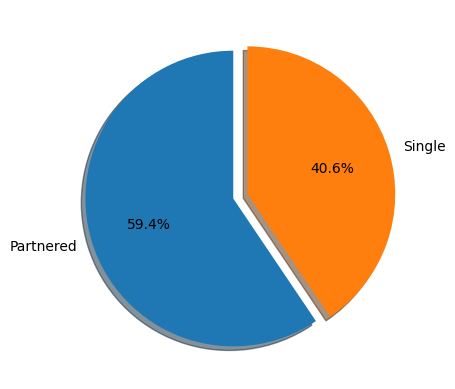

In [23]:
# Visualizing marital status distribution
plt.pie(x=df["MaritalStatus"].value_counts(), labels=df["MaritalStatus"].value_counts().index, autopct='%1.1f%%', explode=(0.1,0), shadow=True, startangle=90)

plt.show()

1. Customers having partners contribute to high purchase with around 60% of purchase share with remaining 40% customers are single.
2. Partnered customers contributing to higher purchases possibly indicating long-term fitness goals, stable income and family planning.

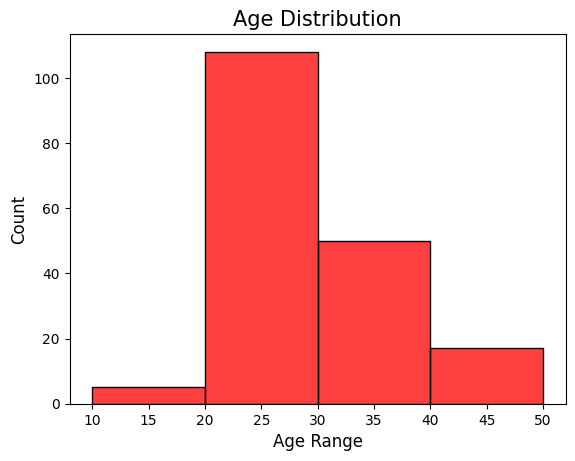

In [24]:
# Visualizing Age distribution
# df["Age"].unique()
bins = [10, 20, 30, 40, 50]

sns.histplot(df, x="Age", bins=bins, color="red")
plt.xlabel("Age Range", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Age Distribution", fontsize=15)

plt.show()

1. Customers in their 20's contribute to the majority of purchases.
2. Customers in their 30's and 40's have comparitively less purchase contribution.
3. Aerofit products seems more popular among the young adults and they may prefer the affordable and beginner friendly product.

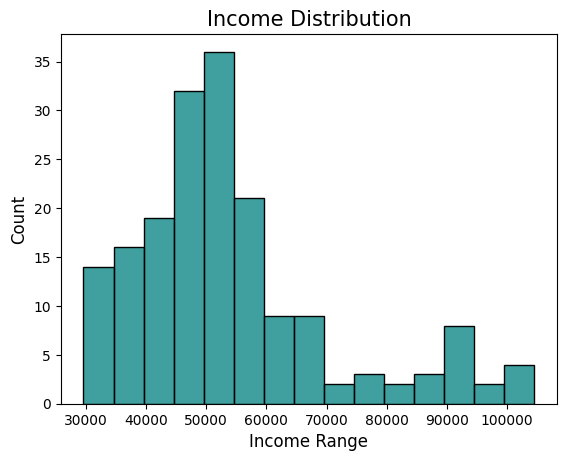

In [25]:
# Visualizing distribution of customers based on their income

sns.histplot(df, x="Income", color="teal")
plt.xlabel("Income Range", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Income Distribution", fontsize=15)

plt.show()

1. Customers with moderate income range contribute to majority of the sales (around 45,000 to 60,000 USD)
2. Higher income group of customers also buy Aerofit products but contribution comparitively less than moderate income range group.
3. Low frequency of higher income group of customers might explain the contribution of premium model KP781 being low.
4. High frequency of low to moderate income group of customers may suggest the purchase of entry product KP281 being the highest.

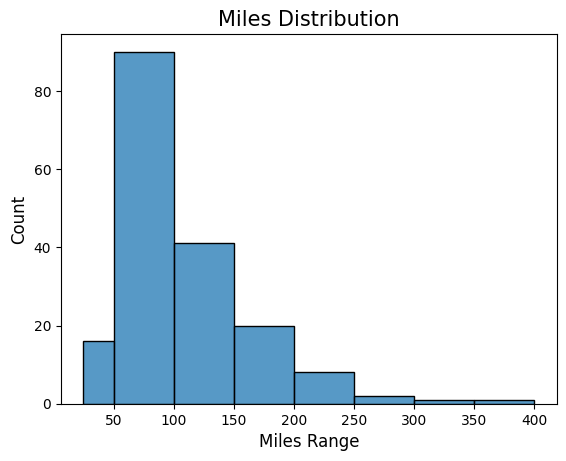

In [26]:
# Visualizing purchase distribution by miles walked/run per week
# df["Miles"].unique()
# df["Miles"].nunique()

sns.histplot(df, x="Miles", bins=[25, 50, 100, 150, 200, 250, 300, 350, 400])
plt.xlabel("Miles Range", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Miles Distribution", fontsize=15)

plt.show()

1. Majority of customers have walked/ran around 50 to 100 miles per week while comparitively less customers have walked/ran above 100 miles per week.
2. Most of the customer base may tend to follow average fitness lifestyle while very less tend to follow heavy or active lifestyle.

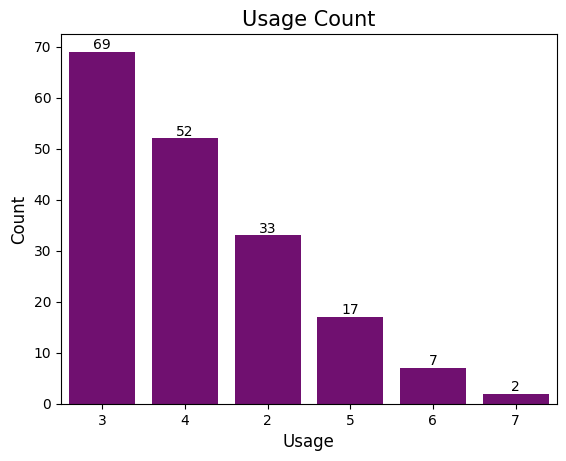

In [27]:
# Visualizing distribution for product usage per week
# df["Usage"].unique()
# df["Usage"].nunique()

ax = sns.countplot(df, x="Usage", order=df["Usage"].value_counts().index, color="purple")
plt.xlabel("Usage", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Usage Count", fontsize=15)

for i in ax.containers:
    ax.bar_label(i)

plt.show()

1. Majority of the customers plan to use the product 3-4 times per week while very less customers plan to use the product almost daily.
2. Majority of the customers belong to moderately active group while very less customers belong to active lifestyle which may explain the product category purchases behaviour.

**Bivariate Analysis** - Product vs Gender

In [28]:
# Product vs Gender comparison using crosstab

product_gender_distro = pd.crosstab(df["Product"], df["Gender"])
product_gender_distro

Gender,Female,Male
Product,,
KP281,40,40
KP481,29,31
KP781,7,33


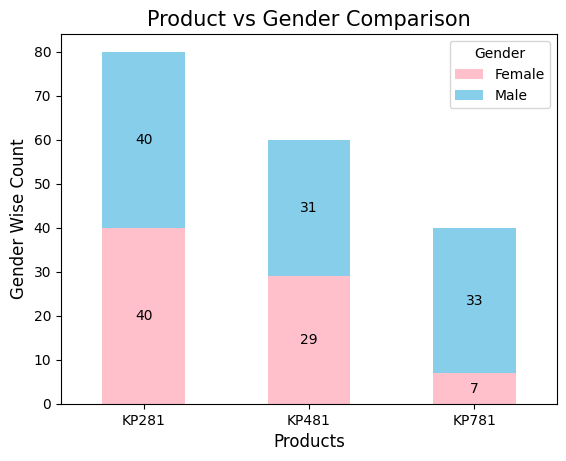

In [29]:
# Visualization of this comparison using stacked bar graph

ax = product_gender_distro.plot(kind="bar", stacked=True, color=["pink", "skyblue"])
plt.xlabel("Products", fontsize=12)
plt.xticks(rotation=0)
plt.ylabel("Gender Wise Count", fontsize=12)
plt.title("Product vs Gender Comparison", fontsize=15)

# labelling values in the bars
for i in ax.containers:
    ax.bar_label(i, label_type="center")

plt.show()

1. Male customers are highest in KP781 product.
2. Male and Female customers are balanced in KP481 and KP281 product.
3. Male dominance is high in KP781 product while females are more concentrated in KP481 and KP281 product.
4. Male dominance in KP781 product suggest males have tendency towards premium models while females contribute more towards KP481 and KP281 models.

**Bivariate Analysis** - Product vs Fitness

In [30]:
# Product vs Fitness comparison using crosstab
product_fitness_comp = pd.crosstab(df["Fitness"], df["Product"])
product_fitness_comp

Product,KP281,KP481,KP781
Fitness,,,
1,1,1,0
2,14,12,0
3,54,39,4
4,9,8,7
5,2,0,29


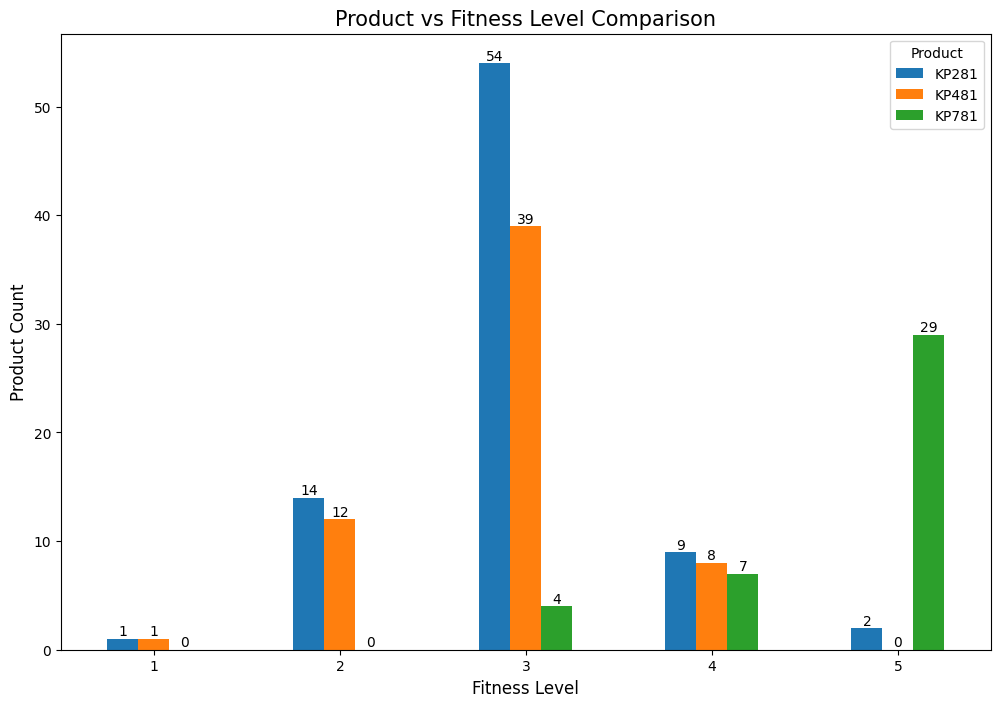

In [31]:
# Visualization of this comparison using grouped bar graph
# plt.figure(figsize=(12,8))
ax = product_fitness_comp.plot(kind="bar", stacked=False, figsize=(12,8))
plt.xlabel("Fitness Level", fontsize=12)
plt.xticks(rotation=0)
plt.ylabel("Product Count", fontsize=12)
plt.title("Product vs Fitness Level Comparison", fontsize=15)

# labelling values in the bars
for i in ax.containers:
    ax.bar_label(i)

plt.show()

1. Fitness level 3 dominates for KP281 and KP481 products.
2. Fitness level 5 dominates for KP781 product.
3. Fitness level 4 has balanced customers for all 3 products.
4. Low to average fitness level users tend to buy KP281 and KP481 products.
5. High fitness level users tend to buy product with advanced features suggesting premium models are preferred by advanced fitness customers

**Bivariate Analysis** - Product vs Income

In [32]:
# Comparing the statisctics based on product
df.groupby("Product")["Income"].describe()

,count,mean,std,min,25%,50%,75%,max
Product,,,,,,,,
KP281,80.0,46418.025,9075.783190,29562.0,38658.00,46617.0,53439.0,68220.0
KP481,60.0,48973.650,8653.989388,31836.0,44911.50,49459.5,53439.0,67083.0
KP781,40.0,75441.575,18505.836720,48556.0,58204.75,76568.5,90886.0,104581.0


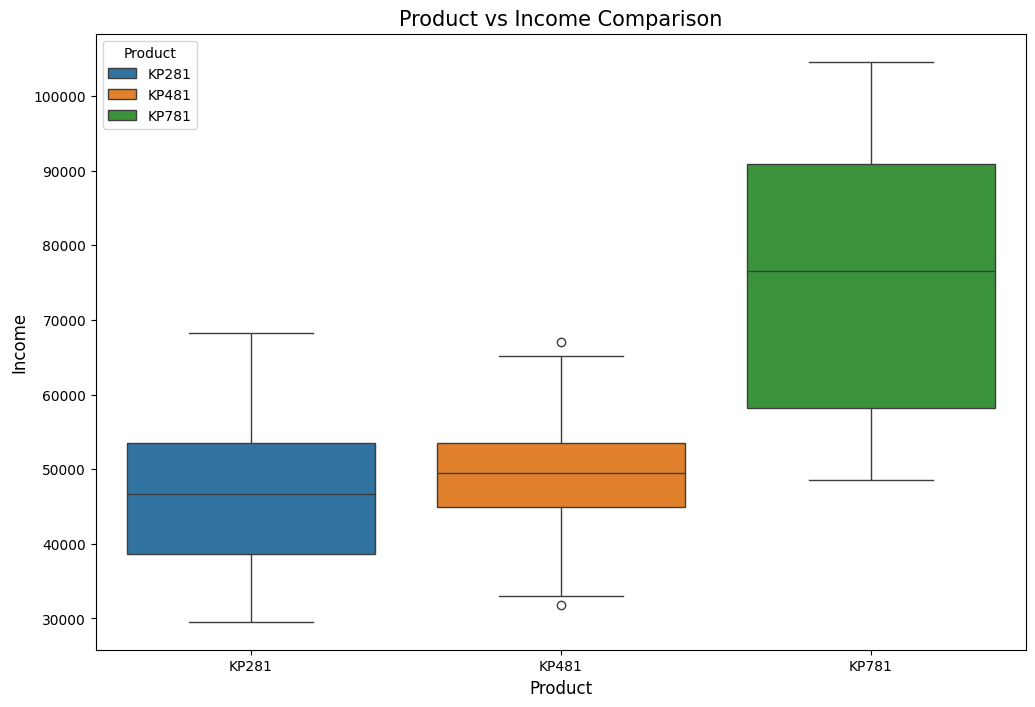

In [33]:
# comparison of product vs customer income
plt.figure(figsize=(12,8))
sns.boxplot(df, x="Product", y="Income", hue="Product", legend=True)
plt.xlabel("Product", fontsize=12)
plt.ylabel("Income", fontsize=12)
plt.title("Product vs Income Comparison", fontsize=15)

plt.show()

1. Customers who have purchased KP781 have the highest median income around 75,000 USD.
2. Customers who have purchased KP281 and KP481 have almost same median income.
3. Income spread or Standard Deviation of income is highest for customers who have purchased KP781.
4. KP781 customers belong to higher income range while KP281 and KP481 customers belong to low to moderate income range.
5. Outlier is observed for KP481 product customers suggesting some customers outside that income range might have purchased KP481 product.

**Correlation Analysis**

In [34]:
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [35]:
# segregating all numerical values for correlation
df_corr = df[["Age", "Education", "Usage", "Fitness", "Income", "Miles"]]
df_corr

,Age,Education,Usage,Fitness,Income,Miles
0,18,14,3,4,29562,112
1,19,15,2,3,31836,75
2,19,14,4,3,30699,66
3,19,12,3,3,32973,85
4,20,13,4,2,35247,47
...,...,...,...,...,...,...
175,40,21,6,5,83416,200
176,42,18,5,4,89641,200
177,45,16,5,5,90886,160
178,47,18,4,5,104581,120


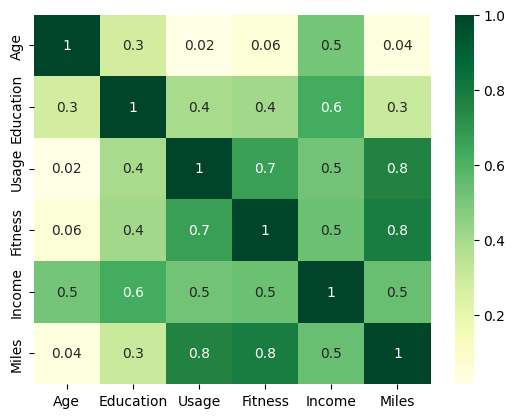

In [36]:
# df_corr.corr()
# plotting heatmap correlation for numerical columns
sns.heatmap(df_corr.corr(), annot=True, fmt='.1g', cmap="YlGn")

plt.show()

1. Usage and Miles show strong positive correlation suggesting that customers who use product more, run/walk more miles per week.
2. Usage and Fitness show strong positive correlation suggesting that customer who use the product more weekly have high fitness level.
3. Fitness and Miles show strong positive correlation suggesting that customer who have high fitness level have ran/walked more miles per week.
4. Income shows moderate positive correlation with Fitness, Usage, and Miles, indicating that higher-income customers may be having active lifestyle.

**Probability Analysis**

In [37]:
# Percentage distribution of product category purchase
np.round(df["Product"].value_counts(normalize=True) * 100, 2)

Product
KP281    44.44
KP481    33.33
KP781    22.22
Name: proportion, dtype: float64

1. Probability of customer purchasing KP281 is 44.44% suggesting it as the most preferred product.
2. Probability of customer purchasing KP481 is 33.33%
3. Probability of customer purchasing KP781 is 22.22% suggesting the premium model purchase is lower comparitively.

**Conditional Probability**

What is the probability of a male customer buying a KP781 treadmill? -- **P(KP781 | Male)**  

In [38]:
# Distribution of male customers for all the products
pd.crosstab(df["Product"], df["Gender"], margins=True)

Gender,Female,Male,All
Product,,,
KP281,40,40,80
KP481,29,31,60
KP781,7,33,40
All,76,104,180


Total number of "Male" customers = 104  
Total number of "KP781" customers = 40  
Customers who are Male and purchased KP781 = 33

P(KP781 | Male) = P( KP781 and Male) / P(Customers who are Male)  
P(KP781 | Male) = P (KP781 and Male) / P(Male)  
P(KP781 | Male) = 33 / 104  
P(KP781 | Male) = 0.317 = 31.7%  

**Probability of a male customer purchasing KP781 is approximately 31.7%.**

### Business Insights

1. The highest sale of KP281 may suggest that most of the customer prefer affordable or beginner-level product.
2. Both genders male and female contribute almost equally to product purchases.
3. Majority of Aerofit customers are moderately active users rather than professional or highly active users.
4. The product with the most advanced features has comparitively less purchase.
5. Partnered customers contributing to higher purchases possibly indicating long-term fitness goals, stable income and family planning.
6. Aerofit products seems more popular among the young adults and they may prefer the affordable and beginner friendly product.
7. Low frequency of higher income group of customers might explain the contribution of premium model KP781 being low.
8. High frequency of low to moderate income group of customers may suggest the purchase of entry product KP281 being the highest.
9. Most of the customer base may tend to follow average fitness lifestyle while very less tend to follow heavy or active lifestyle.
10. Majority of the customers belong to moderately active group while very less customers belong to active lifestyle.
11. Low to average fitness level users tend to buy KP281 and KP481 products.
13. High fitness level users tend to buy product with advanced features suggesting premium models are preferred by advanced fitness customers.
14. KP781 customers belong to higher income range while KP281 and KP481 customers belong to low to moderate income range.
15. Outlier is observed for KP481 product customers suggesting some customers outside that income range might have purchased KP481 product.
16. Usage and Miles show strong positive correlation suggesting that customers who use product more, run/walk more miles per week.
17. Usage and Fitness show strong positive correlation suggesting that customer who use the product more weekly have high fitness level.
18. Fitness and Miles show strong positive correlation suggesting that customer who have high fitness level have ran/walked more miles per week.
19. Income shows moderate positive correlation with Fitness, Usage, and Miles, indicating that higher-income customers may be having active lifestyle.
20. Probability of a male customer purchasing KP781 is approximately 31.7%

### Business Recommendations

1. Promote features and benefits of medium and premium model to average fitness level customers to increase purchase of those models.
2. Provide a subscription plan on premium models like weight loss program and stamina improvement program to encourage customers to purchase premium models.
3. Promote discounts and free supplementary gadgets like fitness tracking wearables on premium models.
4. Target low and moderate budget customers giving them exclusive discounts on upgrading their treadmill product.
5. Promote fitness importance and healthy lifestyle awareness targeted towards female customers to improve female engagement in products.
6. Engagement on social media and ad campaign regarding product benefits and healthy lifestyle importance to attract more customers.
7. Collaborate with a brand ambassador who is a fitness expert to promote Aerofit models and spread awareness of fitness and active lifestyle.